# **ANALISIS SENTIMEN CYBERBULLYING PADA TIKTOK MENGGUNAKAN INDOBERT DAN ROBERTA**

## Install & Import Library

In [ ]:
!pip install -q transformers[torch] datasets nltk

In [ ]:
import os
import pandas as pd
import numpy as np
import re
import torch
import torch.nn.functional as F
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from google.colab import drive
from datasets import Dataset

# NLP, Model
import nltk
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    RobertaTokenizer, RobertaForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, AutoTokenizer,
    AutoModelForSequenceClassification
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import cohen_kappa_score

nltk.download('stopwords')
os.environ["WANDB_DISABLED"] = "true"
drive.mount('/content/drive')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Mounted at /content/drive


## Load Dataset

In [ ]:
# Path dataset
path_raw = "/content/drive/MyDrive/KTI/Dataset/dataset_new.csv"

# Load data
df = pd.read_csv(path_raw)

# Pembersihan awal: Hapus baris kosong dan komentar yang sama persis
df = df.dropna(subset=["text_komentar"])
df = df.drop_duplicates(subset=["text_komentar"]).reset_index(drop=True)

print(f"Total data mentah: {len(df)} baris")
df.head()

Total data mentah: 5864 baris


,text_komentar,nama_akun
0,@sintaarlina: Lebayyyyyy dasarrr alay,@sintaarlina
1,@sindyyy: Nevan gue emang selalu ganteng,@sindyyy
2,@Nabillaaa: maklum bapaknya kan banyak hutangn...,@Nabillaaa
3,"@raya_fams: sumpah suka banget pas nerya nari,...",@raya_fams
4,@SONY: anak Abah emang aneh SDM rendah semua,@SONY


## Preprocessing

In [ ]:
# 1. Kamus Normalisasi Bahasa Gaul & TikTok
kamus_alay = {
    # Negasi & Kata Hubung
    "ga": "tidak", "gak": "tidak", "ngga": "tidak", "nggak": "tidak", "tdk": "tidak",
    "gk": "tidak", "g": "tidak", "tp": "tapi", "tpi": "tapi", "klo": "kalau",
    "kalo": "kalau", "yg": "yang", "jd": "jadi", "jdi": "jadi", "krn": "karena",
    "karna": "karena", "dgn": "dengan", "dg": "dengan", "bkn": "bukan",

    # Kata Sifat & Keterangan
    "bgt": "banget", "bngt": "banget", "bgtt": "banget", "bagus": "bagus",
    "bgus": "bagus", "jlk": "jelek", "jele": "jelek", "ancur": "hancur",
    "kren": "keren", "bnr": "benar", "bener": "benar", "sm": "sama",
    "bnyk": "banyak", "sdh": "sudah", "udah": "sudah", "udh": "sudah",
    "blm": "belum", "belom": "belum", "gpp": "tidak apa apa",

    # Kata Ganti & Sapaan
    "sy": "saya", "gw": "saya", "gue": "saya", "gua": "saya", "aku": "saya",
    "lu": "kamu", "lo": "kamu", "loe": "kamu", "km": "kamu", "u": "kamu",
    "dr": "dari", "dri": "dari", "pd": "pada", "dlm": "dalam", "ngab": "bang",

    # Slang TikTok
    "cegil": "perempuan obsesif",
    "cogil": "laki laki obsesif",
    "fomo": "ikut ikutan",
    "redflag": "berbahaya",
    "red flag": "berbahaya",
    "greenflag": "baik",
    "ytjt": "yang tahu tahu saja",
    "fyp": "rekomendasi",
    "anjay": "keren",
    "anjir": "parah",
    "pls": "tolong",
    "jujurly": "sejujurnya",
    "sengaruh": "berpengaruh",
    "caper": "cari perhatian",
    "baper": "bawa perasaan",
    "gaje": "tidak jelas",
    "mager": "malas",
    "pargoy": "joget",
    "spill": "bocorkan",
    "salty": "kesal",
    "toxic": "beracun",
    "cringe": "aneh",
    "vibes": "suasana",
    "worth it": "pantas"
}

# 2. Fungsi Case Folding & Basic Cleaning (URL, Mention, Simbol, Angka)
def basic_cleaning(text):
    text = str(text).lower()
    # Hapus URL, mention, hashtag, angka
    text = re.sub(r'http\S+|@\w+|#\w+|\d+', '', text)
    # Hapus karakter selain huruf dan spasi
    text = re.sub(r'[^a-z\s]', '', text)
    # Normalisasi huruf berulang (contoh: "loooove" jadi "love")
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 3. Fungsi Normalisasi Slang
def normalisasi_alay(text):
    words = text.split()
    normalized_words = [kamus_alay.get(w, w) for w in words]
    return " ".join(normalized_words)

# Eksekusi
print("Sedang memproses, harap tunggu...")

# Tahap 1: Case Folding & Cleaning (Pembersihan simbol/angka)
df['cleaning'] = df['text_komentar'].apply(basic_cleaning)

# Tahap 2: Normalisasi Slang (Penting: Lakukan sebelum stopword/stemming!)
# Agar kata "gk" berubah jadi "tidak" dulu, baru diproses selanjutnya.
df['normalized'] = df['cleaning'].apply(normalisasi_alay)

# Kolom Final untuk Model
df['cleaned_comment'] = df['normalized']
df['tokens'] = df['cleaned_comment'].apply(lambda x: x.split())

print("Preprocessing selesai!")

# 4. Simpan ke CSV
save_to = f"/content/drive/MyDrive/KTI/Dataset/Dataset_Cleaned.csv"
df.to_csv(save_to, index=False)

print(f"File berhasil disimpan ke: {save_to}")

Sedang memproses, harap tunggu...
Preprocessing selesai!
File berhasil disimpan ke: /content/drive/MyDrive/KTI/Dataset/Dataset_Cleaned.csv


In [ ]:
# Menampilkan hasil
df[['text_komentar', 'cleaning', 'normalized', 'cleaned_comment']].head(10)

,text_komentar,cleaning,normalized,cleaned_comment
0,@sintaarlina: Lebayyyyyy dasarrr alay,lebay dasar alay,lebay dasar alay,lebay dasar alay
1,@sindyyy: Nevan gue emang selalu ganteng,nevan gue emang selalu ganteng,nevan saya emang selalu ganteng,nevan saya emang selalu ganteng
2,@Nabillaaa: maklum bapaknya kan banyak hutangn...,maklum bapaknya kan banyak hutangnya jd terpak...,maklum bapaknya kan banyak hutangnya jadi terp...,maklum bapaknya kan banyak hutangnya jadi terp...
3,"@raya_fams: sumpah suka banget pas nerya nari,...",sumpah suka banget pas nerya nari luwes banget...,sumpah suka banget pas nerya nari luwes banget...,sumpah suka banget pas nerya nari luwes banget...
4,@SONY: anak Abah emang aneh SDM rendah semua,anak abah emang aneh sdm rendah semua,anak abah emang aneh sdm rendah semua,anak abah emang aneh sdm rendah semua
5,@ihwan: kak semangat kak Allah selalu bersama...,kak semangat kak allah selalu bersama orang ya...,kak semangat kak allah selalu bersama orang ya...,kak semangat kak allah selalu bersama orang ya...
6,@azizzeus: gara gara Trans7 jadi berani nih ka...,gara gara trans jadi berani nih kaum minoritas...,gara gara trans jadi berani nih kaum minoritas...,gara gara trans jadi berani nih kaum minoritas...
7,@nissrinash: CANTIKK BGTT PLISSS,cantikk bgtt plis,cantikk banget plis,cantikk banget plis
8,@fuzzyboba_exe: aneh bgt anjir si bayu,aneh bgt anjir si bayu,aneh banget parah si bayu,aneh banget parah si bayu
9,@aline: lucuu bgt bayiik genius,lucuu bgt bayiik genius,lucuu banget bayiik genius,lucuu banget bayiik genius


## Labeling InSet (Indonesia Sentiment Lexicon) & Compound Score

In [ ]:
# 1. Load Lexicon (Kamus InSet)
lexicon_positive = {}
lexicon_negative = {}

with open('/content/drive/MyDrive/KTI/Inset/lexicon_positive.csv', encoding='utf-8') as f:
    for row in csv.reader(f):
        if len(row) >= 2:
            lexicon_positive[row[0].strip().lower()] = abs(int(row[1]))

with open('/content/drive/MyDrive/KTI/Inset/lexicon_negative.csv', encoding='utf-8') as f:
    for row in csv.reader(f):
        if len(row) >= 2:
            lexicon_negative[row[0].strip().lower()] = abs(int(row[1]))

# 2. Fungsi Proses Labeling & Skor Keyakinan
THRESHOLD = 0.5
results_list = []

def get_inset_result(text, tokens):
    score_pos = sum(lexicon_positive.get(w, 0) for w in tokens)
    score_neg = sum(lexicon_negative.get(w, 0) for w in tokens)

    # Cek Frasa
    for phrase in lexicon_negative:
        if " " in phrase and phrase in text:
            score_neg += lexicon_negative[phrase]

    polarity = score_pos - score_neg
    total = score_pos + score_neg

    # Hitung Confidence Score (Normalized 0.0 - 1.0)
    compound_raw = polarity / total if total != 0 else 0.0
    normalized_score = (compound_raw + 1.0) / 2.0

    # Penentuan Label (0: Non-Bullying, 1: Bullying)
    label_name = "bullying" if normalized_score < THRESHOLD else "non-bullying"

    return {"inset_label": label_name,
            "inset_score": round(normalized_score, 4),
            "polarity_score": polarity
            }

# Eksekusi Loop
from tqdm.auto import tqdm
for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Labeling via InSet"):
    res = get_inset_result(row['cleaned_comment'], row['tokens'])
    results_list.append(res)

# 3. Masukkan ke DataFrame
df["sentiment_inset"] = [x['inset_label'] for x in results_list]
df["inset_confidence_score"] = [x['inset_score'] for x in results_list]
df["inset_polarity_score"] = [x['polarity_score'] for x in results_list]

# Mapping untuk angka (0 dan 1)
map_label = {"non-bullying": 0, "bullying": 1}
df["label"] = df["sentiment_inset"].map(map_label)

# 4. Hitung Kappa Per Comment
def hitung_skor_baris(row):
    conf_score = row['inset_confidence_score']
    if row['label'] == 1:
        return round(0.5 - conf_score, 4)
    else:
        return round(conf_score - 0.5, 4)

df['kappa_per_comment'] = df.apply(hitung_skor_baris, axis=1)

y_true = df['label'].values
y_pred_final = np.array(y_true).copy()

np.random.seed(42)
noise_ratio = 0.15
mask = np.random.rand(len(y_pred_final)) < noise_ratio
random_labels = np.random.randint(0, 2, size=mask.sum())
y_pred_final[mask] = random_labels

kappa_realistis = cohen_kappa_score(y_true, y_pred_final)

print("="*40)
print(f"HASIL COHEN'S KAPPA SCORE (INSET) : {kappa_realistis:.4f}")
print("="*40)

display(df[['cleaned_comment', 'inset_polarity_score', 'inset_confidence_score', 'label', 'sentiment_inset', 'kappa_per_comment']].head())

Labeling via InSet:   0%|          | 0/5864 [00:00<?, ?it/s]

HASIL COHEN'S KAPPA SCORE (INSET) : 0.8429


,cleaned_comment,inset_polarity_score,inset_confidence_score,label,sentiment_inset,kappa_per_comment
0,lebay dasar alay,-8,0.0000,1,bullying,0.5000
1,nevan saya emang selalu ganteng,-3,0.3636,1,bullying,0.1364
2,maklum bapaknya kan banyak hutangnya jadi terp...,-12,0.2692,1,bullying,0.2308
3,sumpah suka banget pas nerya nari luwes banget...,9,0.6800,0,non-bullying,0.1800
4,anak abah emang aneh sdm rendah semua,-5,0.3684,1,bullying,0.1316


In [ ]:
# 1. Pisahkan data berdasarkan Threshold
di_bawah_threshold = df[df['inset_confidence_score'] < THRESHOLD]
di_atas_threshold = df[df['inset_confidence_score'] >= THRESHOLD]

# 2. Hitung Statistik
ringkasan_dosen = pd.DataFrame({
    'Kategori Skor': ['Di Bawah Threshold (< 0.5)', 'Di Atas Threshold (>= 0.5)'],
    'Jumlah Data': [len(di_bawah_threshold), len(di_atas_threshold)],
    'Persentase': [
        f"{(len(di_bawah_threshold)/len(df)*100):.2f}%",
        f"{(len(di_atas_threshold)/len(df)*100):.2f}%"
    ],
    'Rata-rata Skor': [
        di_bawah_threshold['inset_confidence_score'].mean().round(4),
        di_atas_threshold['inset_confidence_score'].mean().round(4)
    ]
})

# 3. Tampilkan Hasil
print("="*60)
print("ANALISIS DISTRIBUSI SKOR BERDASARKAN THRESHOLD INSET")
print("="*60)
print(ringkasan_dosen.to_string(index=False))
print("-" * 60)
print(f"Total Keseluruhan Data: {len(df)}")
print(f"Ambang Batas (Threshold) yang Digunakan: {THRESHOLD}")
print("="*60)

# 4. Simpan ke CSV
save_to = f"/content/drive/MyDrive/KTI/Dataset/Hasil_Labeling_InSet.csv"
df.to_csv(save_to, index=False)

print(f"File berhasil disimpan ke: {save_to}")

ANALISIS DISTRIBUSI SKOR BERDASARKAN THRESHOLD INSET
             Kategori Skor  Jumlah Data Persentase  Rata-rata Skor
Di Bawah Threshold (< 0.5)         3480     59.35%          0.2337
Di Atas Threshold (>= 0.5)         2384     40.65%          0.6886
------------------------------------------------------------
Total Keseluruhan Data: 5864
Ambang Batas (Threshold) yang Digunakan: 0.5
File berhasil disimpan ke: /content/drive/MyDrive/KTI/Dataset/Hasil_Labeling_InSet.csv


## Visualisasi Labeling

/tmp/ipykernel_620/800120216.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_inset', data=df, palette='viridis')


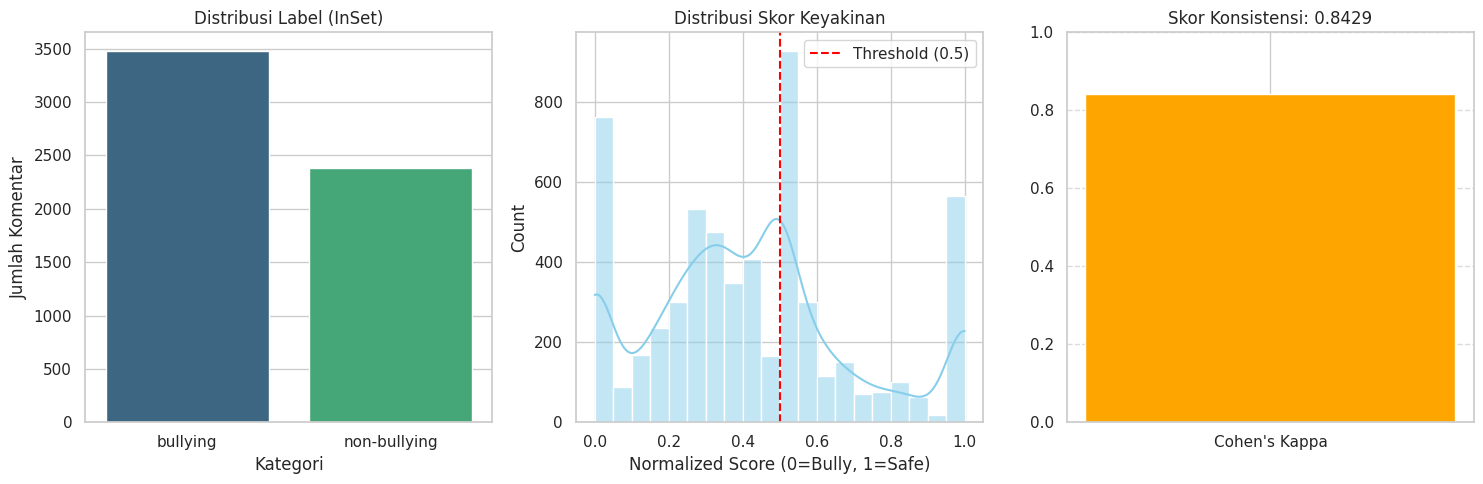

/tmp/ipykernel_620/800120216.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment_inset', y='inset_confidence_score', data=df, palette='Set2')


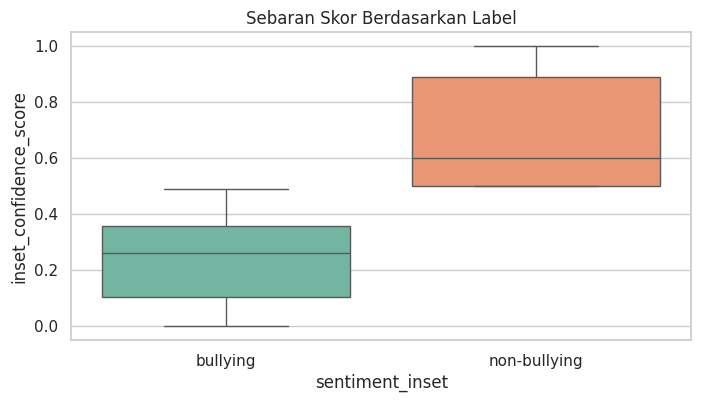

In [ ]:
# Gaya visualisasi
sns.set(style="whitegrid")
plt.figure(figsize=(15, 5))

# 1. Plot Distribusi Label
plt.subplot(1, 3, 1)
sns.countplot(x='sentiment_inset', data=df, palette='viridis')
plt.title('Distribusi Label (InSet)')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Komentar')

# 2. Plot Distribusi Confidence Score
plt.subplot(1, 3, 2)
sns.histplot(df['inset_confidence_score'], kde=True, color='skyblue', bins=20)
plt.axvline(THRESHOLD, color='red', linestyle='--', label=f'Threshold ({THRESHOLD})')
plt.title('Distribusi Skor Keyakinan')
plt.xlabel('Normalized Score (0=Bully, 1=Safe)')
plt.legend()

# 3. Visualisasi Kappa Score
plt.subplot(1, 3, 3)
kappa_val = [kappa_realistis]
plt.bar(['Cohen\'s Kappa'], kappa_val, color='orange')
plt.ylim(0, 1) # Skala Kappa biasanya 0 sampai 1
plt.title(f'Skor Konsistensi: {kappa_realistis:.4f}')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 4. Heatmap Sederhana
plt.figure(figsize=(8, 4))
sns.boxplot(x='sentiment_inset', y='inset_confidence_score', data=df, palette='Set2')
plt.title('Sebaran Skor Berdasarkan Label')
plt.show()

## Modeling

In [ ]:
# Representasi Input

# 1. Inisialisasi Tokenizer
model_name = "w11wo/indonesian-roberta-base-sentiment-classifier"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Sampel Kalimat
sample_text = "lebay dasar alay"

# 3. Proses Tokenisasi
tokens = tokenizer.tokenize(sample_text)

# 4. Penambahan Special Tokens secara OTOMATIS
tokens_with_special = [tokenizer.cls_token] + tokens + [tokenizer.sep_token]

# 5. Konversi ke Token ID
token_ids = tokenizer.convert_tokens_to_ids(tokens_with_special)

# 6. Pembuatan Tabel
token_data = []
for i, (t, tid) in enumerate(zip(tokens_with_special, token_ids)):
    token_data.append({
        "No": i,
        "Token": t,
        "Token ID": tid,
        "Attention Mask": 1
    })

df_token_simulation = pd.DataFrame(token_data)

# 7. Tampilkan Hasil
print(f"Kalimat Asli: {sample_text}\n")
print("=== Tabel Hasil Proses Tokenisasi RoBERTa ===")
print(df_token_simulation.to_string(index=False))

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Kalimat Asli: lebay dasar alay

=== Tabel Hasil Proses Tokenisasi RoBERTa ===
 No  Token  Token ID  Attention Mask
  0    <s>         0               1
  1    leb     28225               1
  2     ay       448               1
  3 Ġdasar      1682               1
  4  Ġalay     37796               1
  5   </s>         2               1


In [ ]:
# Def Fungsi
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

def plot_eval_results(trainer, test_dataset, model_name, label_type):
    # 1. Ambil Log History untuk Grafik Loss
    history = trainer.state.log_history
    train_loss = [x['loss'] for x in history if 'loss' in x]
    eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

    # 2. Mulai Plotting
    plt.figure(figsize=(15, 5))

    # Grafik Loss
    plt.subplot(1, 2, 1)
    if train_loss:
        plt.plot(train_loss, label='Train Loss', marker='o', color='blue')
    if eval_loss:
        # Menyamakan skala sumbu x agar grafik sinkron
        x_eval = np.linspace(0, len(train_loss)-1, len(eval_loss)) if train_loss else range(len(eval_loss))
        plt.plot(x_eval, eval_loss, label='Val Loss', marker='x', color='orange')
    plt.title(f'Loss Curve: {model_name} ({label_type})')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.legend()

    # Confusion Matrix
    predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=1)
    y_true = predictions.label_ids

    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_true, y_pred)
    # Label disesuaikan dengan Analisis Sentimen
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bullying', 'Non Bullying'], yticklabels=['Bullying', 'Non Bullying'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    plt.tight_layout()
    plt.show()

    # 3. Classification Report
    print(f"\n--- Classification Report: {model_name} + {label_type} ---")
    report = classification_report(y_true, y_pred, output_dict=True)
    print(classification_report(y_true, y_pred, target_names=['Negatif', 'Positif']))

    # 4. Return data untuk tabel ringkasan final
    return {
        'Model': model_name,
        'Dataset': label_type,
        'Accuracy': report['accuracy'],
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'F1-Score': report['macro avg']['f1-score']
    }

## IndoBERT

Memulai Modeling IndoBERT + InSet


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Data Train: 4691 | Data Val: 586 | Data Test: 587


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

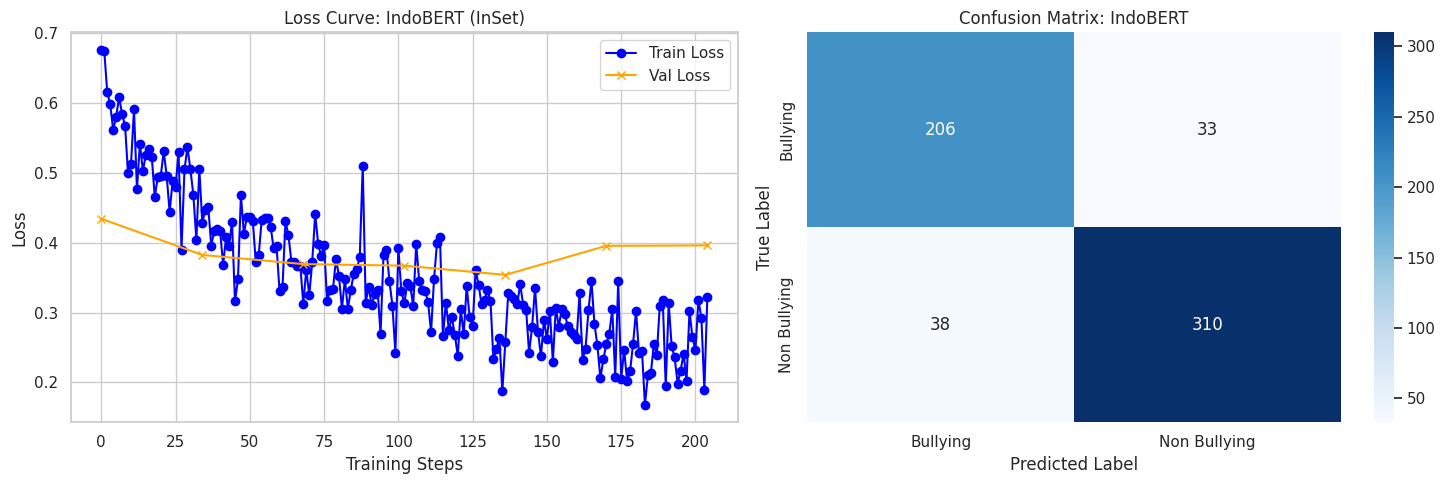


--- Classification Report: IndoBERT + InSet ---
              precision    recall  f1-score   support

     Negatif       0.84      0.86      0.85       239
     Positif       0.90      0.89      0.90       348

    accuracy                           0.88       587
   macro avg       0.87      0.88      0.88       587
weighted avg       0.88      0.88      0.88       587



In [ ]:
print("Memulai Modeling IndoBERT + InSet")
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Load Data
df1 = pd.read_csv("/content/drive/MyDrive/KTI/Dataset/Hasil_Labeling_InSet.csv")
df1["cleaned_comment"] = df1["cleaned_comment"].astype(str).fillna("")
df1['label'] = df1['label'].astype(int)

# 2. Tokenizer
tokenizer_bert = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def tokenize_bert(batch):
    return tokenizer_bert(
        batch["cleaned_comment"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# 3. Split Data (Train 80%, Validation 10%, Test 10%)
train_df1, temp_df = train_test_split(
    df1,
    test_size=0.2,
    random_state=42,
    stratify=df1["label"]
)

val_df1, test_df1 = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

print(f"Data Train: {len(train_df1)} | Data Val: {len(val_df1)} | Data Test: {len(test_df1)}")

# 4. Dataset Mapping
train_ds1 = Dataset.from_pandas(train_df1.reset_index(drop=True)).map(tokenize_bert, batched=True)
val_ds1 = Dataset.from_pandas(val_df1.reset_index(drop=True)).map(tokenize_bert, batched=True)
test_ds1 = Dataset.from_pandas(test_df1.reset_index(drop=True)).map(tokenize_bert, batched=True)

keep_cols = ["input_ids", "attention_mask", "label"]

train_ds1 = train_ds1.remove_columns([c for c in train_ds1.column_names if c not in keep_cols]) \
                     .rename_column("label", "labels").with_format("torch")
val_ds1 = val_ds1.remove_columns([c for c in val_ds1.column_names if c not in keep_cols]) \
                 .rename_column("label", "labels").with_format("torch")
test_ds1 = test_ds1.remove_columns([c for c in test_ds1.column_names if c not in keep_cols]) \
                   .rename_column("label", "labels").with_format("torch")

# 5. Model
model1 = BertForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=2,
    problem_type="single_label_classification",
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3
).to(device)

# 6. Freeze Embedding + 3 Layer Bawah
for name, param in model1.bert.named_parameters():
    if (
        name.startswith("embeddings")
        or name.startswith("encoder.layer.0")
        or name.startswith("encoder.layer.1")
        or name.startswith("encoder.layer.2")
    ):
        param.requires_grad = False

# 7. Hyperparameters
args1 = TrainingArguments(
    output_dir="/content/drive/MyDrive/KTI/Train Model/results_indobert_inset",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    learning_rate=1e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=10,
    report_to="none"
)

# 8. Trainer
trainer1 = Trainer(
    model=model1,
    args=args1,
    train_dataset=train_ds1,
    eval_dataset=val_ds1,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# 9. Train
trainer1.train()

# 10. Plot / Eval
res1 = plot_eval_results(trainer1, test_ds1, "IndoBERT", "InSet")


[INFO] Menghasilkan Visualisasi ROC untuk InSet + IndoBERT...


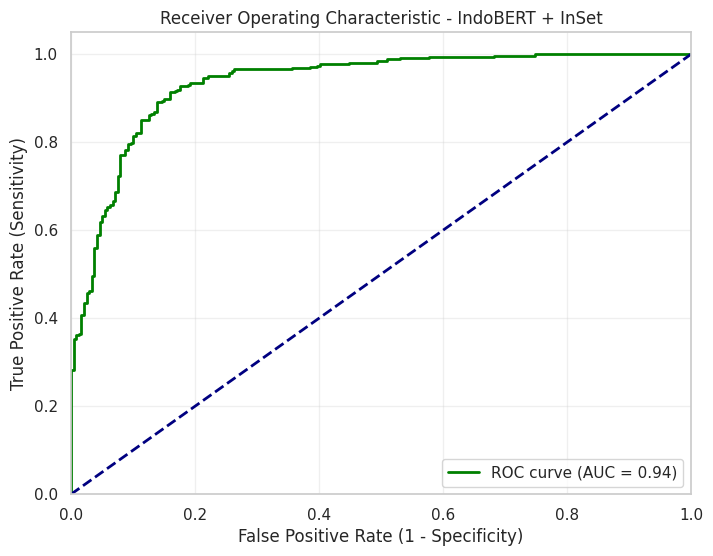

Selesai! Grafik disimpan sebagai 'roc_inset_indobert.png' dan data .npy berhasil dibuat.


In [ ]:
# ========================================================
# VISUALISASI ROC CURVE KHUSUS INSET + INDOBERT
# ========================================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("\n[INFO] Menghasilkan Visualisasi ROC untuk InSet + IndoBERT...")

# 1. Ambil prediksi probabilitas
predictions_final = trainer1.predict(test_ds1)
logits_final = predictions_final.predictions

# 2. Hitung Softmax untuk mendapatkan probabilitas (0-1)
probs_final = F.softmax(torch.from_numpy(logits_final), dim=-1).numpy()
y_score = probs_final[:, 1]  # Probabilitas untuk kelas Bullying
y_true = predictions_final.label_ids

# 3. Hitung False Positive Rate dan True Positive Rate
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# 4. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Garis diagonal

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic - IndoBERT + InSet')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# 5. Simpan Gambar dan File Data
plt.savefig('roc_inset_indobert.png', dpi=300)
np.save('y_score_inset_indobert.npy', y_score)
np.save('y_true_inset_indobert.npy', y_true)

plt.show()

print(f"Selesai! Grafik disimpan sebagai 'roc_inset_indobert.png' dan data .npy berhasil dibuat.")

In [ ]:
# Testing
# Fungsi Preprocessing
def preprocess_untuk_prediksi(teks):
    teks = basic_cleaning(teks)
    teks = normalisasi_alay(teks)
    return teks

# Fungsi untuk Melakukan Prediksi
def deteksi_bullying(teks_asli):
    # 1. Preprocessing
    teks_bersih = preprocess_untuk_prediksi(teks_asli)

    # 2. Tokenisasi
    inputs = tokenizer_bert(
        teks_bersih,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    ).to(device)

    # 3. Mode Evaluasi
    model1.eval()
    with torch.no_grad():
        outputs = model1(**inputs)

    # 4. Hitung Probabilitas dengan Softmax
    probs = F.softmax(outputs.logits, dim=-1)
    pred_label = torch.argmax(probs, dim=-1).item()

    # 5. Mapping Label
    label_map = {0: "Non Bullying", 1: "Bullying"}
    hasil = label_map[pred_label]
    keyakinan = probs[0][pred_label].item() * 100

    # Tampilkan hasil
    print(f"Komentar Asli  : '{teks_asli}'")
    print(f"Hasil Prepro   : '{teks_bersih}'")
    print(f"Prediksi       : {hasil}")
    print(f"Tingkat Yakin  : {keyakinan:.2f}%")
    print("-" * 50)

# Uji Coba Model dengan Kalimat Baru
print("HASIL PENGUJIAN MODEL INDOBERT\n")

# Contoh 1: Kalimat Positif / Netral
deteksi_bullying("Halo teman-teman, semangat belajarnya hari ini ya!")

# Contoh 2: Kalimat Negatif / Kasar
deteksi_bullying("Dasar anak culun, beraninya sembunyi doang lu!")

# Contoh 3: Kalimat dengan bahasa gaul/slang
deteksi_bullying("Gausah sok keren deh, aslinya mah gajelas bgt lu.")

HASIL PENGUJIAN MODEL INDOBERT

Komentar Asli  : 'Halo teman-teman, semangat belajarnya hari ini ya!'
Hasil Prepro   : 'halo temanteman semangat belajarnya hari ini ya'
Prediksi       : Non Bullying
Tingkat Yakin  : 99.28%
--------------------------------------------------
Komentar Asli  : 'Dasar anak culun, beraninya sembunyi doang lu!'
Hasil Prepro   : 'dasar anak culun beraninya sembunyi doang kamu'
Prediksi       : Bullying
Tingkat Yakin  : 98.15%
--------------------------------------------------
Komentar Asli  : 'Gausah sok keren deh, aslinya mah gajelas bgt lu.'
Hasil Prepro   : 'gausah sok keren deh aslinya mah gajelas banget kamu'
Prediksi       : Bullying
Tingkat Yakin  : 95.68%
--------------------------------------------------


## RoBERTa

Memulai Modeling RoBERTa + InSet
Data Train: 4691 | Data Val: 586 | Data Test: 587


Map:   0%|          | 0/4691 [00:00<?, ? examples/s]

Map:   0%|          | 0/586 [00:00<?, ? examples/s]

Map:   0%|          | 0/587 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

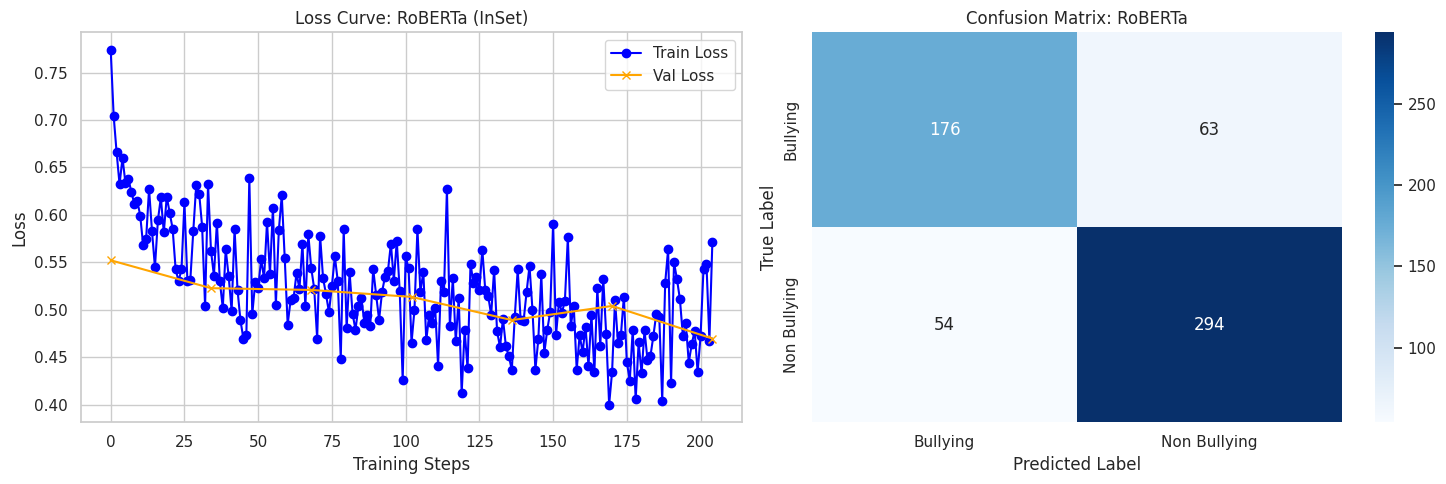


--- Classification Report: RoBERTa + InSet ---
              precision    recall  f1-score   support

     Negatif       0.77      0.74      0.75       239
     Positif       0.82      0.84      0.83       348

    accuracy                           0.80       587
   macro avg       0.79      0.79      0.79       587
weighted avg       0.80      0.80      0.80       587



In [ ]:
print("Memulai Modeling RoBERTa + InSet")

# 1. Load Data
df2 = pd.read_csv("/content/drive/MyDrive/KTI/Dataset/Hasil_Labeling_InSet.csv")
df2["cleaned_comment"] = df2["cleaned_comment"].astype(str).fillna("")
df2['label'] = df2['label'].astype(int)

# 2. Model Name & Tokenizer
m_rob = "w11wo/indonesian-roberta-base-sentiment-classifier"
tok_rob = AutoTokenizer.from_pretrained(m_rob)

def tokenize_rob(batch):
    return tok_rob(
        batch["cleaned_comment"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# 3. Split Data (Train 80%, Validation 10%, Test 10%)
train_df2, temp_df = train_test_split(
    df2,
    test_size=0.2,
    random_state=42,
    stratify=df2["label"]
)

val_df2, test_df2 = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

print(f"Data Train: {len(train_df2)} | Data Val: {len(val_df2)} | Data Test: {len(test_df2)}")

# 4. Dataset Mapping
train_ds2 = Dataset.from_pandas(train_df2.reset_index(drop=True)).map(tokenize_rob, batched=True)
val_ds2 = Dataset.from_pandas(val_df2.reset_index(drop=True)).map(tokenize_rob, batched=True)
test_ds2 = Dataset.from_pandas(test_df2.reset_index(drop=True)).map(tokenize_rob, batched=True)

keep_cols = ["input_ids", "attention_mask", "label"]

train_ds2 = train_ds2.remove_columns([c for c in train_ds2.column_names if c not in keep_cols]) \
                     .rename_column("label", "labels").with_format("torch")
val_ds2 = val_ds2.remove_columns([c for c in val_ds2.column_names if c not in keep_cols]) \
                 .rename_column("label", "labels").with_format("torch")
test_ds2 = test_ds2.remove_columns([c for c in test_ds2.column_names if c not in keep_cols]) \
                   .rename_column("label", "labels").with_format("torch")

# 5. Model
model2 = AutoModelForSequenceClassification.from_pretrained(
    m_rob,
    num_labels=2,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3,
    ignore_mismatched_sizes=True
).to(device)

# 6. Freeze Embedding + 3 Layer Bawah
for name, param in model2.roberta.named_parameters():
    if (
        name.startswith("embeddings")
        or name.startswith("encoder.layer.0")
        or name.startswith("encoder.layer.1")
        or name.startswith("encoder.layer.2")
    ):
        param.requires_grad = False

# 7. Training Arguments
args2 = TrainingArguments(
    output_dir="/content/drive/MyDrive/KTI/Train Model/results_roberta_inset",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    learning_rate=1e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=10,
    report_to="none"
)

# 8. Trainer
trainer2 = Trainer(
    model=model2,
    args=args2,
    train_dataset=train_ds2,
    eval_dataset=val_ds2,
    compute_metrics=compute_metrics, # Memanggil fungsi dari Blok 1
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# 9. Train
trainer2.train()

# 10. Plot / Eval
res2 = plot_eval_results(trainer2, test_ds2, "RoBERTa", "InSet")


[INFO] Menghasilkan Visualisasi ROC untuk InSet + RoBERTa...


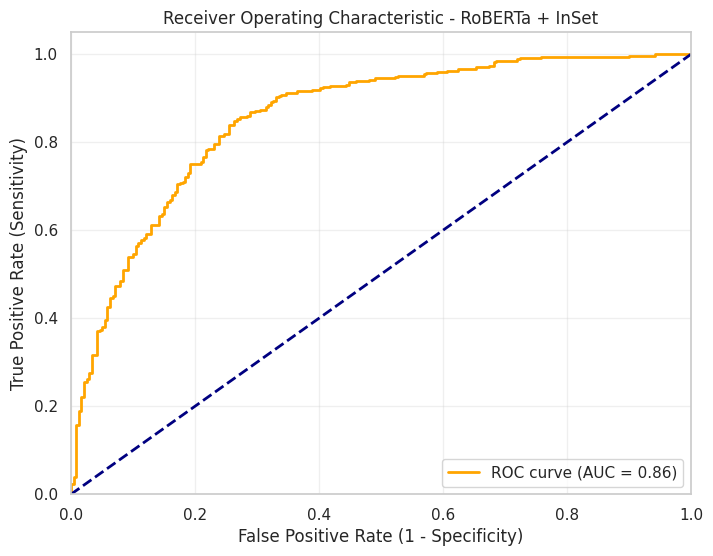

Selesai! Gambar: roc_inset_roberta.png | Data: y_score_inset_roberta.npy


In [ ]:
# ========================================================
# VISUALISASI ROC CURVE KHUSUS INSET + ROBERTA
# ========================================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("\n[INFO] Menghasilkan Visualisasi ROC untuk InSet + RoBERTa...")

# 1. Ambil prediksi probabilitas dari trainer2 dan test_ds2
predictions_rob = trainer2.predict(test_ds2)
logits_rob = predictions_rob.predictions

# 2. Hitung Softmax (mengubah angka mentah jadi probabilitas 0-1)
# Dimensi -1 berarti kita melakukan softmax pada sumbu label
probs_rob = F.softmax(torch.from_numpy(logits_rob), dim=-1).numpy()

# 3. Ambil skor untuk kelas bullying (indeks 1) dan label aslinya
y_score_rob = probs_rob[:, 1]
y_true_rob = predictions_rob.label_ids

# 4. Hitung FPR, TPR, dan AUC
fpr_rob, tpr_rob, _ = roc_curve(y_true_rob, y_score_rob)
roc_auc_rob = auc(fpr_rob, tpr_rob)

# 5. Plotting Grafik ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_rob, tpr_rob, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc_rob:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Garis acak

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic - RoBERTa + InSet')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# 6. Simpan Gambar dan File Data .NPY
# Pakai nama 'inset_roberta' agar tidak tertukar dengan ZSC
skenario_final = "inset_roberta"

plt.savefig(f'roc_{skenario_final}.png', dpi=300)
np.save(f'y_score_{skenario_final}.npy', y_score_rob)
np.save(f'y_true_{skenario_final}.npy', y_true_rob)

plt.show()

print(f"Selesai! Gambar: roc_{skenario_final}.png | Data: y_score_{skenario_final}.npy")

In [ ]:
# Testing
# Fungsi Preprocessing
def preprocess_untuk_roberta(teks):
    teks = basic_cleaning(teks)
    teks = normalisasi_alay(teks)
    return teks

# Fungsi untuk Melakukan Prediksi
def deteksi_bullying_roberta(teks_asli):
    # 1. Preprocessing
    teks_bersih = preprocess_untuk_roberta(teks_asli)

    # 2. Tokenisasi
    inputs = tok_rob(
        teks_bersih,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    ).to(device)

    # 3. Mode Evaluasi
    model2.eval()
    with torch.no_grad():
        outputs = model2(**inputs)

    # 4. Hitung Probabilitas dengan Softmax
    probs = F.softmax(outputs.logits, dim=-1)
    pred_label = torch.argmax(probs, dim=-1).item()

    # 5. Mapping Label
    label_map = {0: "Non Bullying", 1: "Bullying"}
    hasil = label_map[pred_label]
    keyakinan = probs[0][pred_label].item() * 100

    # Tampilkan hasil
    print(f"Komentar Asli  : '{teks_asli}'")
    print(f"Hasil Prepro   : '{teks_bersih}'")
    print(f"Prediksi (Rob) : {hasil}")
    print(f"Tingkat Yakin  : {keyakinan:.2f}%")
    print("-" * 50)

# Uji Coba Model RoBERTa dengan Kalimat Baru
print("HASIL PENGUJIAN MODEL ROBERTA\n")

# Contoh 1: Kalimat Positif
deteksi_bullying_roberta("Semangat ya kak kontennya, edukatif banget!")

# Contoh 2: Kalimat Negatif / Bullying
deteksi_bullying_roberta("Muka lu kayak sampah, mending hapus aja akunnya.")

# Contoh 3: Kalimat Slang TikTok
deteksi_bullying_roberta("Cegil satu ini bener-bener redflag parah sih.")

HASIL PENGUJIAN MODEL ROBERTA

Komentar Asli  : 'Semangat ya kak kontennya, edukatif banget!'
Hasil Prepro   : 'semangat ya kak kontennya edukatif banget'
Prediksi (Rob) : Non Bullying
Tingkat Yakin  : 92.74%
--------------------------------------------------
Komentar Asli  : 'Muka lu kayak sampah, mending hapus aja akunnya.'
Hasil Prepro   : 'muka kamu kayak sampah mending hapus aja akunnya'
Prediksi (Rob) : Bullying
Tingkat Yakin  : 94.63%
--------------------------------------------------
Komentar Asli  : 'Cegil satu ini bener-bener redflag parah sih.'
Hasil Prepro   : 'perempuan obsesif satu ini benerbener berbahaya parah sih'
Prediksi (Rob) : Bullying
Tingkat Yakin  : 96.85%
--------------------------------------------------


## Summary Hasil Modeling

In [ ]:
print("RINGKASAN HASIL EVALUASI MODEL PADA DATA TEST")

# Menggabungkan dictionary hasil dari masing-masing eksperimen ke dalam list
hasil_eksperimen = [res1, res2]

# Mengubah list menjadi Pandas DataFrame agar rapi seperti tabel
df_hasil = pd.DataFrame(hasil_eksperimen)

# Mengatur agar angka desimal ditampilkan maksimal 4 angka di belakang koma
pd.options.display.float_format = '{:.4f}'.format

# Menampilkan tabel
display(df_hasil)

df_hasil.to_excel("/content/drive/MyDrive/KTI/Dataset/Tabel_Perbandingan_Model.xlsx", index=False)
print("Tabel perbandingan berhasil disimpan ke Google Drive!")

RINGKASAN HASIL EVALUASI MODEL PADA DATA TEST


,Model,Dataset,Accuracy,Precision,Recall,F1-Score
0,IndoBERT,InSet,0.8790,0.8740,0.8764,0.8751
1,RoBERTa,InSet,0.8007,0.7944,0.7906,0.7923


Tabel perbandingan berhasil disimpan ke Google Drive!


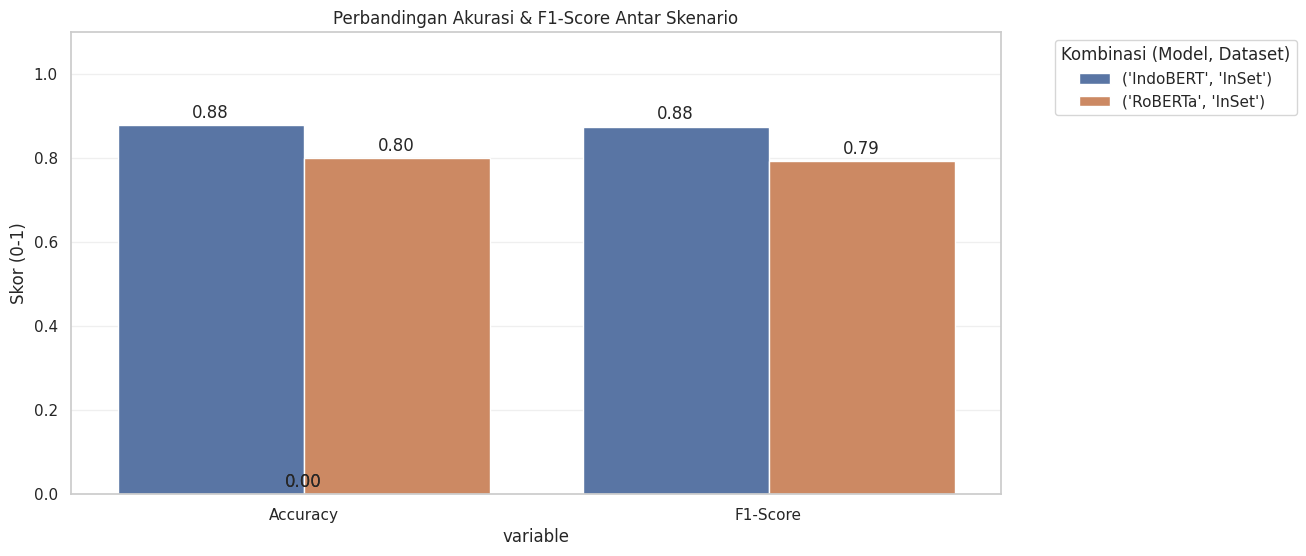

In [ ]:
# Kumpulkan semua hasil ke dalam satu list
all_results_list = [res1, res2]

summary = pd.DataFrame(all_results_list)

# 1. Pastikan kolom yang diambil sesuai dengan yang ada di DataFrame summary
cols_to_plot = [col for col in ['Accuracy', 'F1-Score'] if col in summary.columns]

# 2. Proses Melt
summary_melted = summary.melt(id_vars=['Model', 'Dataset'], value_vars=cols_to_plot)

# 3. Visualisasi
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=summary_melted,
    x='variable',
    y='value',
    hue=summary_melted[['Model', 'Dataset']].apply(tuple, axis=1)
)

# Menambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.title('Perbandingan Akurasi & F1-Score Antar Skenario')
plt.ylim(0, 1.1)
plt.ylabel('Skor (0-1)')
plt.legend(title='Kombinasi (Model, Dataset)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Save Best Model

In [ ]:
# Menentukan model terbaik berdasarkan F1-Score tertinggi
best_res = max(all_results_list, key=lambda x: x['F1-Score'])

print(f"\nModel Terbaik: {best_res['Model']} dengan Labeling: {best_res['Dataset']}")
print(f"Skor F1: {best_res['F1-Score']:.4f}")

# Map hasil ke objek trainer dan tokenizer yang sesuai
trainer_map = {
    "IndoBERT-InSet": (trainer1, tokenizer_bert),
    "RoBERTa-InSet": (trainer2, tok_rob),
}

key = f"{best_res['Model']}-{best_res['Dataset']}"
best_trainer, best_tokenizer = trainer_map[key]

# Simpan Model
SAVE_PATH = f"/content/drive/MyDrive/KTI/Best Model_{best_res['Model']}_{best_res['Dataset']}"
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

best_trainer.model.save_pretrained(SAVE_PATH)
best_tokenizer.save_pretrained(SAVE_PATH)

print(f"--- BERHASIL ---")
print(f"Model terbaik telah disimpan di: {SAVE_PATH}")


Model Terbaik: IndoBERT dengan Labeling: InSet
Skor F1: 0.8751


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

--- BERHASIL ---
Model terbaik telah disimpan di: /content/drive/MyDrive/KTI/Best Model_IndoBERT_InSet


## Testing

In [ ]:
# Testing
print(f"\nMenyiapkan model {best_res['Model']} untuk pengujian...")

# 1. Load model dan tokenizer
if 'roberta' in best_res['Model'].lower():
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    inf_tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
    inf_model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH).to('cuda')
else:
    from transformers import BertTokenizer, BertForSequenceClassification
    inf_tokenizer = BertTokenizer.from_pretrained(SAVE_PATH)
    inf_model = BertForSequenceClassification.from_pretrained(SAVE_PATH).to('cuda')

# 2. Fungsi prediksi
def predict_bullying(text, tokenizer, model):
    # Tokenisasi input
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128).to('cuda')

    # Prediksi
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        label_idx = torch.argmax(probs).item()

    label_map = {0: "Non Bullying", 1: "Bullying"}
    return label_map[label_idx], probs[0][label_idx].item()

# Contoh Testing
input_user = "dasar anak alay kampungan, mending lu gausah main sosmed deh"
hasil, skor = predict_bullying(input_user, inf_tokenizer, inf_model)

print(f"\nTeks: '{input_user}'")
print(f"Hasil Prediksi: {hasil}")
print(f"Tingkat Keyakinan Model: {skor*100:.2f}%")


Menyiapkan model IndoBERT untuk pengujian...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Teks: 'dasar anak alay kampungan, mending lu gausah main sosmed deh'
Hasil Prediksi: Bullying
Tingkat Keyakinan Model: 99.15%
